LIBRARIES

In [19]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import datetime as dt



DATASET

In [3]:

downloads_path = "C:/Users/HP/Downloads"


for file in os.listdir(downloads_path):
    if file.endswith(".csv"):
        csv_path = os.path.join(downloads_path, file)
        print("Loading:", csv_path)
        df = pd.read_csv(csv_path)
        break




Loading: C:/Users/HP/Downloads\Innoworq_sample.csv


In [4]:

df.columns = df.columns.str.strip().str.replace(" ", "_").str.lower()

print(df.columns.tolist())

['customer_id', 'age', 'gender', 'tenure', 'monthly_usage', 'support_tickets', 'avg_payment_delay_days', 'subscription_type', 'contract_length', 'total_spend', 'last_active_date', 'churn']


In [5]:
print(df.head())

   customer_id  age  gender  tenure  monthly_usage  support_tickets  \
0            1   22  Female      25             14                4   
1            2   41  Female      28             28                7   
2            3   47    Male      27             10                2   
3            4   35    Male       9             12                5   
4            5   53  Female      58             24                9   

   avg_payment_delay_days subscription_type contract_length  total_spend  \
0                      27             Basic         Monthly          598   
1                      13          Standard         Monthly          584   
2                      29           Premium          Annual          757   
3                      17           Premium       Quarterly          232   
4                       2          Standard          Annual          533   

  last_active_date churn  
0       09-01-1900   Yes  
1               20    No  
2               21    No  
3       

In [6]:

df['last_active_date'] = pd.to_datetime(df['last_active_date'], errors='coerce')



In [7]:

df.loc[df['last_active_date'] < '2000-01-01', 'last_active_date'] = pd.NaT


In [8]:
df['gender'] = df['gender'].str.title().str.strip()
df['subscription_type'] = df['subscription_type'].str.title().str.strip()
df['contract_length'] = df['contract_length'].str.title().str.strip()
df['churn'] = df['churn'].str.title().str.strip()   # Yes/No



In [9]:

df.drop_duplicates(inplace=True)


In [10]:
df.fillna({
    'support_tickets': 0,
    'avg_payment_delay_days': df['avg_payment_delay_days'].median()
}, inplace=True)


In [31]:
snapshot_date = df['last_active_date'].max() + pd.Timedelta(days=1)

# --- RFM Feature Engineering ---
rfm = df.groupby('customer_id').agg({
    'tenure': 'max',            #  recency
    'monthly_usage': 'sum',     # frequency
    'total_spend': 'sum'        # monetary
}).rename(columns={
    'tenure': 'recency',
    'monthly_usage': 'frequency',
    'total_spend': 'monetary'
}).reset_index()

print(rfm.head())

# --- Clustering ---
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['recency','frequency','monetary']])

kmeans = KMeans(n_clusters=3, random_state=42)
rfm['cluster'] = kmeans.fit_predict(rfm_scaled)

print(rfm.groupby('cluster').mean())


   customer_id  recency  frequency  monetary
0            1       25         14       598
1            2       28         28       584
2            3       27         10       757
3            4        9         12       232
4            5       58         24       533
          customer_id    recency  frequency    monetary
cluster                                                
0        29606.103302  12.800420  14.229955  513.251710
1        34083.378382  42.988903  15.421306  314.452944
2        32960.885713  40.834799  15.617131  795.219407


In [32]:
df_final = df.merge(rfm[['customer_id','recency','frequency','monetary','cluster']], on='customer_id', how='left')
df_final.to_excel(r"C:\Users\HP\Downloads\Customer_Sales_Insights.xlsx", index=False)

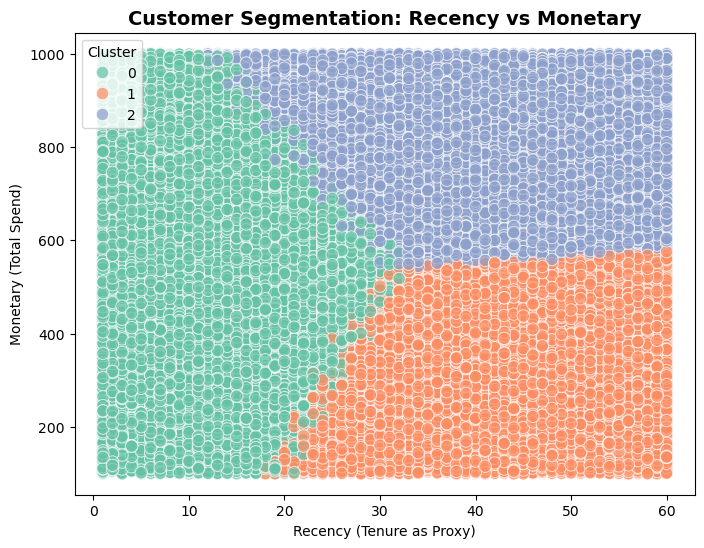

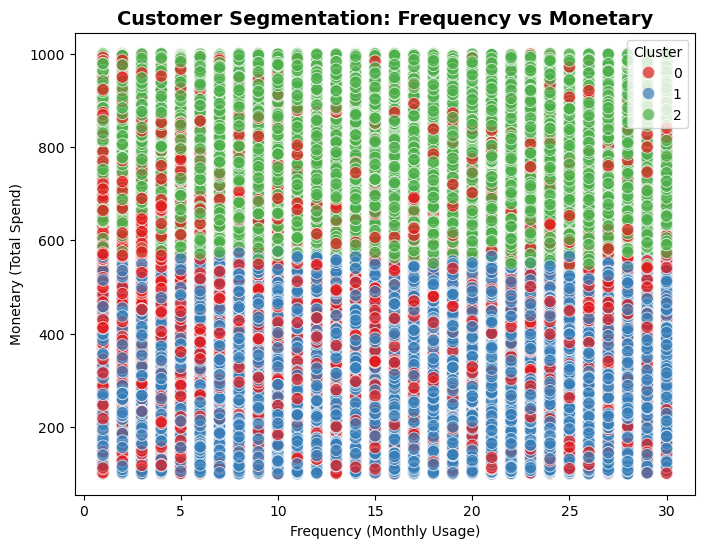

In [34]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=rfm, x='recency', y='monetary',
    hue='cluster', palette='Set2', s=80, alpha=0.7
)
plt.title("Customer Segmentation: Recency vs Monetary", fontsize=14, weight='bold')
plt.xlabel("Recency (Tenure as Proxy)")
plt.ylabel("Monetary (Total Spend)")
plt.legend(title="Cluster")
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=rfm, x='frequency', y='monetary',
    hue='cluster', palette='Set1', s=80, alpha=0.7
)
plt.title("Customer Segmentation: Frequency vs Monetary", fontsize=14, weight='bold')
plt.xlabel("Frequency (Monthly Usage)")
plt.ylabel("Monetary (Total Spend)")
plt.legend(title="Cluster")
plt.show()